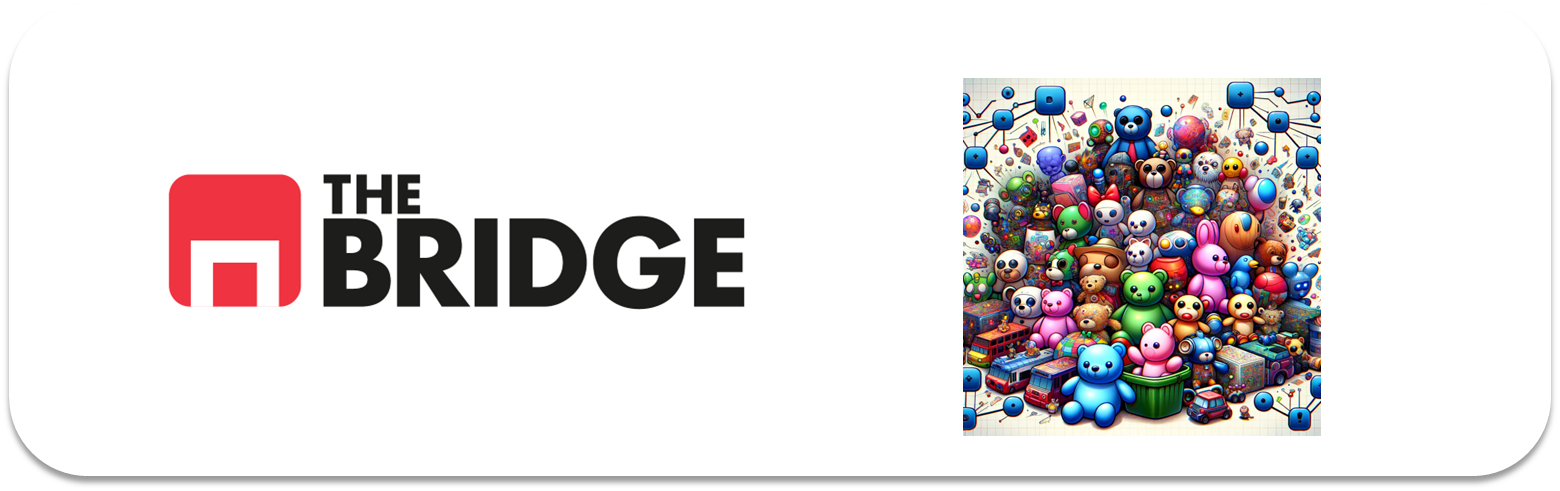

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors


### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


Shape: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB

Nulos por columna:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


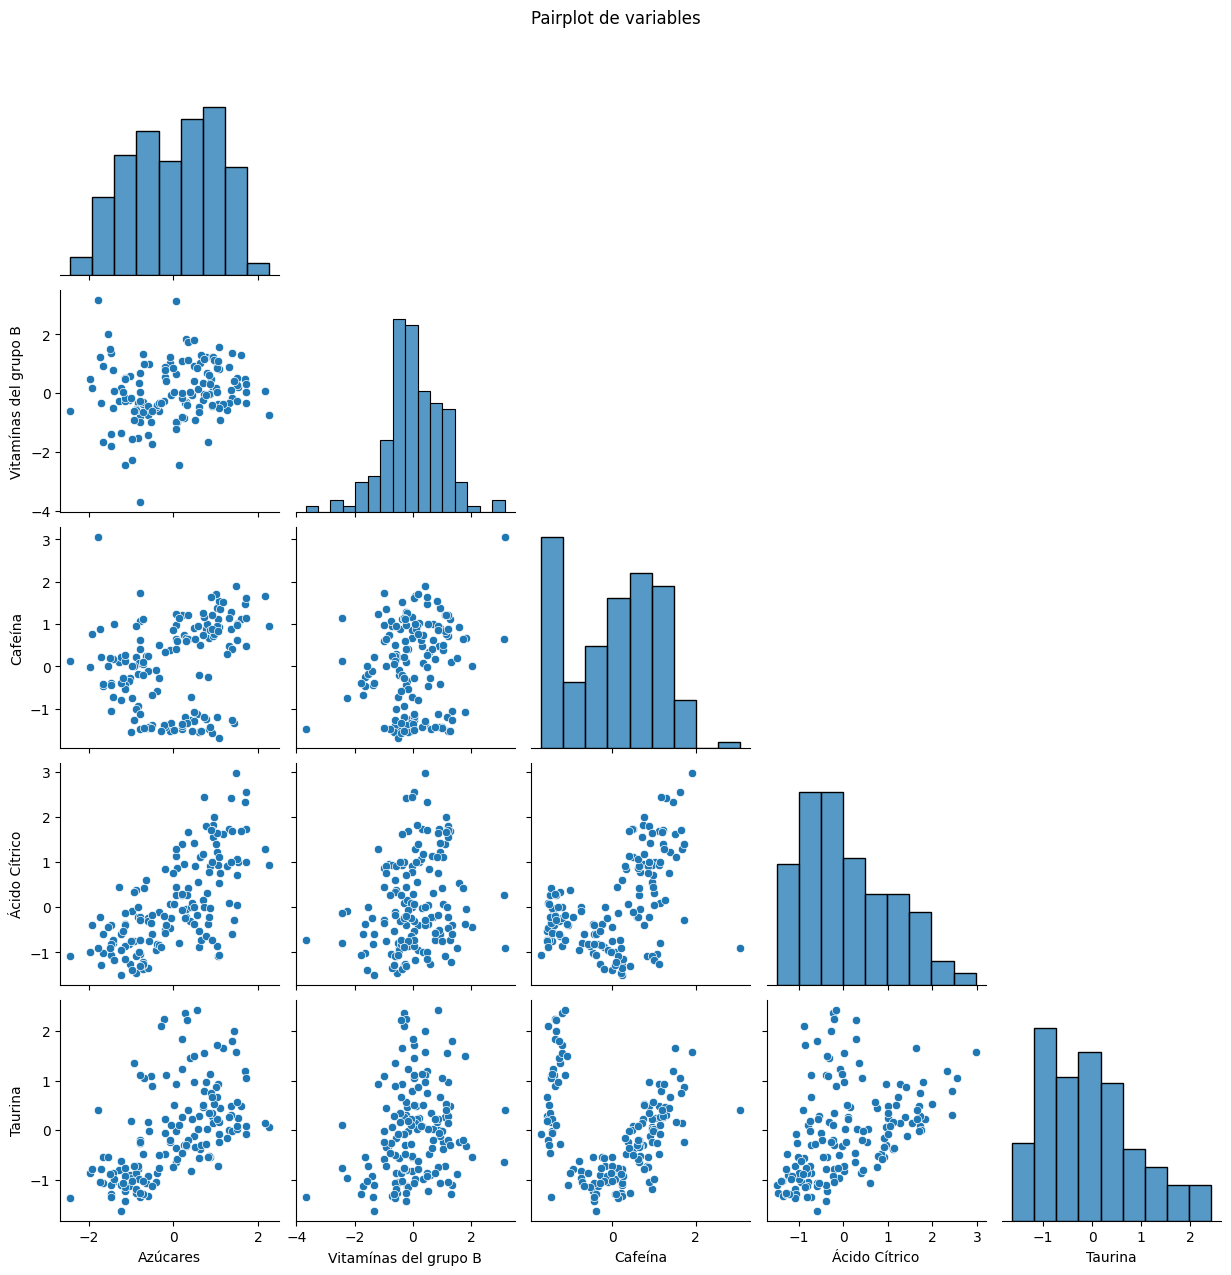


Mejor DBSCAN encontrado:
eps                 0.5
min_samples           4
n_clusters            3
n_noise             140
noise_ratio    0.915033
silhouette      0.61914
Name: 16, dtype: object

Mejor Agglomerative encontrado:
n_clusters           3
linkage           ward
silhouette    0.376469
Name: 0, dtype: object


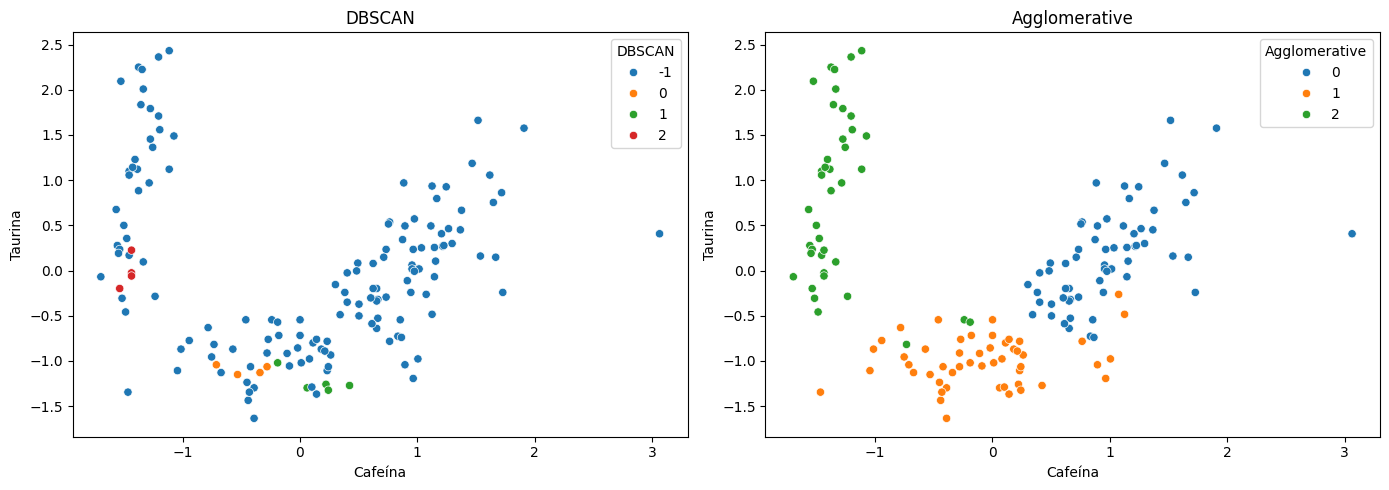


Discusion breve:
- DBSCAN detecta densidades y puede marcar ruido (-1).
- Agglomerative fuerza asignacion total y permite relaciones jerarquicas.
- La comparacion es especulativa porque no hay target de negocio en esta fase.


In [3]:
# ==============================
# Parte I. Modelado
# ==============================
# 1) Carga
path_base = "./data"
df = pd.read_csv(f"{path_base}/empowering_drinks.csv", sep="|")

print("Shape:", df.shape)
display(df.head())
print("\nInfo:")
df.info()
print("\nNulos por columna:")
print(df.isna().sum())

# 2) MiniEDA
sns.pairplot(df, corner=True, diag_kind="hist")
plt.suptitle("Pairplot de variables", y=1.02)
plt.show()

# 3) Escalado
scaler = StandardScaler()
X = scaler.fit_transform(df)

# 4) Modelo 1: DBSCAN (grid simple buscando 3-5 clusters)
param_grid = {
    "eps": np.arange(0.35, 1.41, 0.05),
    "min_samples": [3, 4, 5, 6, 8],
}

dbscan_results = []
for eps in param_grid["eps"]:
    for ms in param_grid["min_samples"]:
        model = DBSCAN(eps=float(eps), min_samples=ms)
        labels = model.fit_predict(X)

        n_noise = np.sum(labels == -1)
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})

        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask]) if mask.sum() > n_clusters else np.nan
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": float(eps),
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": int(n_noise),
            "noise_ratio": n_noise / len(labels),
            "silhouette": sil,
            "labels": labels,
        })

res_db = pd.DataFrame(dbscan_results)

# Filtramos candidatos orientativos de 3 a 5 clusters
cand_db = res_db[
    (res_db["n_clusters"].between(3, 5))
    & (res_db["silhouette"].notna())
].copy()

if len(cand_db) == 0:
    # Fallback si no hay candidatos 3-5
    cand_db = res_db[res_db["silhouette"].notna()].copy()

# Elegimos priorizando mayor silueta y menor ruido
cand_db = cand_db.sort_values(["silhouette", "noise_ratio"], ascending=[False, True])
best_db_row = cand_db.iloc[0]

best_dbscan = DBSCAN(eps=best_db_row["eps"], min_samples=int(best_db_row["min_samples"]))
labels_db = best_dbscan.fit_predict(X)

print("\nMejor DBSCAN encontrado:")
print(best_db_row[["eps", "min_samples", "n_clusters", "n_noise", "noise_ratio", "silhouette"]])

# 5) Modelo 2: Clustering Jerarquico (Agglomerative), probamos 3-5 clusters
agg_results = []
for n_clusters in [3, 4, 5]:
    for linkage in ["ward", "complete", "average"]:
        # ward solo admite euclidean (por defecto)
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)
        agg_results.append({
            "n_clusters": n_clusters,
            "linkage": linkage,
            "silhouette": sil,
            "labels": labels,
        })

res_agg = pd.DataFrame(agg_results).sort_values("silhouette", ascending=False)
best_agg_row = res_agg.iloc[0]

best_agg = AgglomerativeClustering(
    n_clusters=int(best_agg_row["n_clusters"]),
    linkage=best_agg_row["linkage"],
)
labels_agg = best_agg.fit_predict(X)

print("\nMejor Agglomerative encontrado:")
print(best_agg_row[["n_clusters", "linkage", "silhouette"]])

# 6) Visualizacion comparativa (usando dos features para inspeccion)
plot_df = df.copy()
plot_df["DBSCAN"] = labels_db
plot_df["Agglomerative"] = labels_agg

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_df,
    x="Cafeína",
    y="Taurina",
    hue="DBSCAN",
    palette="tab10",
    ax=ax[0],
)
ax[0].set_title("DBSCAN")

sns.scatterplot(
    data=plot_df,
    x="Cafeína",
    y="Taurina",
    hue="Agglomerative",
    palette="tab10",
    ax=ax[1],
)
ax[1].set_title("Agglomerative")

plt.tight_layout()
plt.show()

print("\nDiscusion breve:")
print("- DBSCAN detecta densidades y puede marcar ruido (-1).")
print("- Agglomerative fuerza asignacion total y permite relaciones jerarquicas.")
print("- La comparacion es especulativa porque no hay target de negocio en esta fase.")

# Guardamos un modelo operativo para la parte II (DBSCAN)
modelo_operativo = "DBSCAN"


### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [4]:
# ==============================
# Parte II. Nuevos experimentos
# ==============================
new_df = pd.read_csv(f"{path_base}/new_experiments.csv", sep="|")
X_new = scaler.transform(new_df)

# Como DBSCAN no tiene predict(), asignamos por proximidad a muestras core.
def dbscan_predict_like(model, X_train_scaled, X_new_scaled):
    labels_train = model.labels_
    core_idx = model.core_sample_indices_
    core_points = X_train_scaled[core_idx]
    core_labels = labels_train[core_idx]

    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(core_points)
    dists, idxs = neigh.kneighbors(X_new_scaled, n_neighbors=1)

    pred_labels = []
    for d, idx in zip(dists.ravel(), idxs.ravel()):
        if d <= model.eps:
            pred_labels.append(int(core_labels[idx]))
        else:
            pred_labels.append(-1)  # ruido / no asignado
    return np.array(pred_labels)

new_labels_db = dbscan_predict_like(best_dbscan, X, X_new)

new_segmented = new_df.copy()
new_segmented["segmento_dbscan"] = new_labels_db

print("Nuevos experimentos segmentados (DBSCAN):")
display(new_segmented)


Nuevos experimentos segmentados (DBSCAN):


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,segmento_dbscan
0,1.481555,0.305159,1.366128,2.239039,0.731870,-1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,-1
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,-1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,-1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,-1
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,-1


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [5]:
# ==============================
# Parte III. EXTRA
# ==============================
# power_results incluye resultados para: dataset inicial (153) + nuevos (6) = 159
results = pd.read_csv(f"{path_base}/power_results.csv")
y_true = results["class"].values

# --- Etiquetas DBSCAN para dataset completo (153+6) ---
labels_db_train = labels_db
labels_db_new = new_labels_db
labels_db_all = np.concatenate([labels_db_train, labels_db_new])

# --- Etiquetas Agglomerative para dataset completo ---
# Para train usamos labels_agg ya calculados.
# Para nuevos: asignamos al cluster jerarquico mas cercano por centroide de train.
centroids_agg = (
    pd.DataFrame(X)
    .assign(cluster=labels_agg)
    .groupby("cluster")
    .mean()
)

# Distancia euclidea a centroides
X_new_df = pd.DataFrame(X_new)
dists = np.linalg.norm(
    X_new_df.values[:, None, :] - centroids_agg.values[None, :, :], axis=2
)
closest_idx = np.argmin(dists, axis=1)
cluster_labels_sorted = centroids_agg.index.to_numpy()
labels_agg_new = cluster_labels_sorted[closest_idx]
labels_agg_all = np.concatenate([labels_agg, labels_agg_new])

assert len(labels_db_all) == len(y_true)
assert len(labels_agg_all) == len(y_true)

# Evaluacion robusta a permutacion de etiquetas
ari_db = adjusted_rand_score(y_true, labels_db_all)
nmi_db = normalized_mutual_info_score(y_true, labels_db_all)

ari_agg = adjusted_rand_score(y_true, labels_agg_all)
nmi_agg = normalized_mutual_info_score(y_true, labels_agg_all)

eval_df = pd.DataFrame({
    "modelo": ["DBSCAN", "Agglomerative"],
    "ARI": [ari_db, ari_agg],
    "NMI": [nmi_db, nmi_agg],
})

print("Comparativa de segmentacion frente a resultados reales:")
display(eval_df.sort_values("ARI", ascending=False))

print("\nInterpretacion:")
print("- ARI/NMI mas altos implican mayor alineacion entre segmentos no supervisados y clases reales.")
print("- Estas metricas no requieren que el id del cluster coincida con el id de clase.")


Comparativa de segmentacion frente a resultados reales:


,modelo,ARI,NMI
1,Agglomerative,0.811373,0.806562
0,DBSCAN,0.007728,0.125168



Interpretacion:
- ARI/NMI mas altos implican mayor alineacion entre segmentos no supervisados y clases reales.
- Estas metricas no requieren que el id del cluster coincida con el id de clase.
